# Cardholder Segmentation & Spend-Growth Propensity: Technical Walkthrough

Full pipeline: exploratory analysis on a synthetic bank's cardholder growth data (a fictional regional bank's card business, viewed from the growth/marketing team's side), a Gaussian Mixture Model segmentation on current-window behavior, a response-propensity model trained on the growth team's past (non-randomized) win-back campaign, and a budget-constrained targeting comparison against two naive alternatives.

> All data here is synthetically generated. No proprietary data, models, or results from any employer are used or implied.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
import shap

from style import set_style, style_ax, add_footnote, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, PALETTE, INK
from segmentation import label_segments, NAME_SETS, SEGMENT_FEATURES, K_RANGE, MAX_INTERPRETABLE_K
from propensity_model import build_features, cumulative_gains, FEATURE_NUM, FEATURE_CAT
from targeting import expected_responders, BUDGET_FRACTION

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Data

12,000 synthetic customers, one row per customer, covering trailing-90-day behavior (recency, order frequency, spend, category mix, checkout authorization decline rate) plus whether the growth team's past win-back campaign reached them and whether they responded.

Two latent traits drive the data, generated independent of each other, then only observed through noisy proxies: `baseline_value` (a customer's long-run spending potential, never written to the data) and current-window engagement (drives recency/frequency/monetary, generated independent of `baseline_value` on purpose). That independence is what makes "dormant" a genuinely mixed segment: some dormant customers are worth winning back, most aren't, and current-behavior segmentation alone can't tell them apart. See `src/generate_data.py` for the full generating process.

In [2]:
df = pd.read_csv("../data/customers.csv")
print(f"{len(df):,} customers")
print(f"Past offer sent: {df['past_offer_sent'].sum():,} ({df['past_offer_sent'].mean():.1%} of customers)")
offered = df[df["past_offer_sent"] == 1]
print(f"Response rate among offered: {offered['responded'].mean():.1%}")
df.head()

12,000 customers
Past offer sent: 5,313 (44.3% of customers)
Response rate among offered: 32.1%


,customer_id,tenure_days,lifetime_orders,recency_days,frequency_90d,monetary_90d,category_diversity,decline_rate,primary_channel,past_offer_sent,responded
0,1936,43,2,147,8,275.12,2,0.214,web,0,NaN
1,6495,394,26,86,6,285.83,3,0.175,android,1,0.0
2,1721,204,8,91,4,148.96,4,0.243,web,1,0.0
3,9121,269,21,19,12,775.61,5,0.289,ios,0,NaN
4,361,82,8,129,7,379.45,3,0.282,ios,0,NaN


## 2. Exploratory analysis

Before any model gets trained: does the data show the "win-back sweet spot" the generator was built around, and is the decoy `decline_rate` feature actually flat?

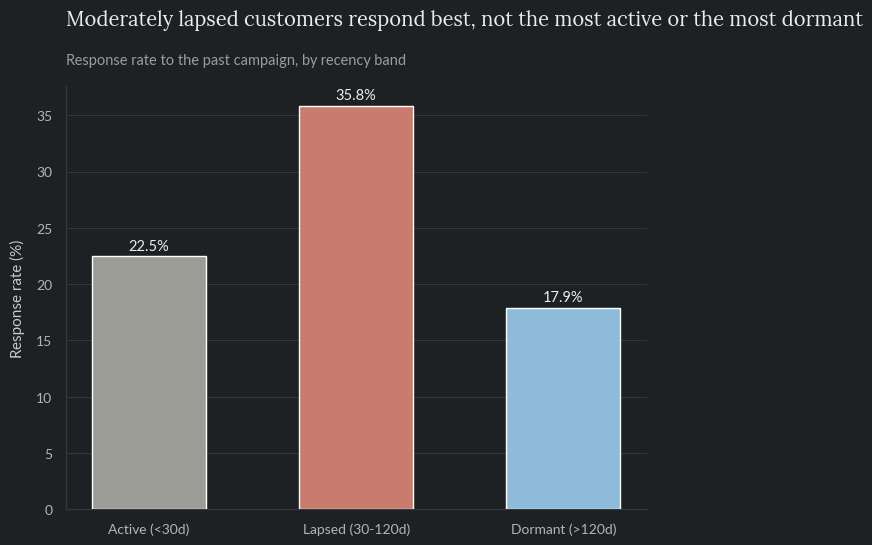

In [3]:
offered = offered.copy()
offered["recency_band"] = pd.cut(offered["recency_days"], [-1, 29, 120, 181],
                                  labels=["Active (<30d)", "Lapsed (30-120d)", "Dormant (>120d)"])
band_rates = offered.groupby("recency_band", observed=True)["responded"].mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = [GREY, MUTED_RED, SLATE]
ax.bar(band_rates.index.astype(str), band_rates.values, color=colors, width=0.55, zorder=3)
for i, v in enumerate(band_rates.values):
    ax.text(i, v + 0.6, f"{v:.1f}%", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Moderately lapsed customers respond best, not the most active or the most dormant",
         subtitle="Response rate to the past campaign, by recency band", ylabel="Response rate (%)")
plt.show()

**Figure 1.** Response rate to the past campaign, by recency band.

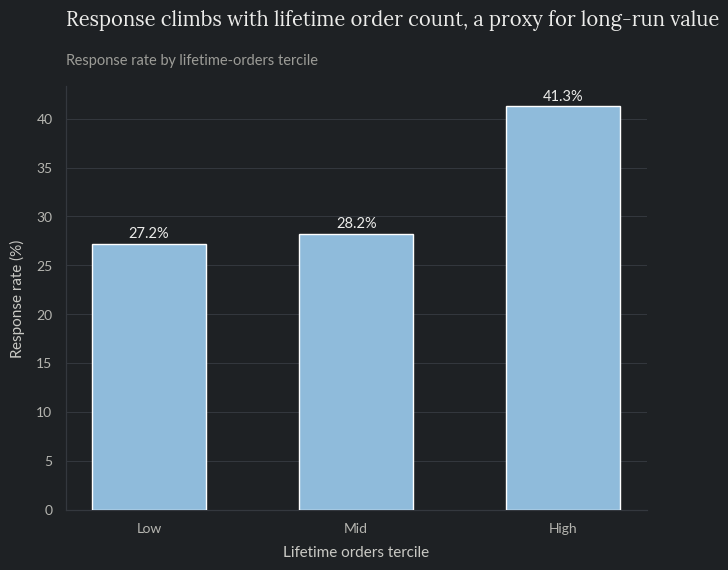

In [4]:
offered["value_tercile"] = pd.qcut(offered["lifetime_orders"], 3, labels=["Low", "Mid", "High"])
value_rates = offered.groupby("value_tercile", observed=True)["responded"].mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.bar(value_rates.index.astype(str), value_rates.values, color=SLATE, width=0.55, zorder=3)
for i, v in enumerate(value_rates.values):
    ax.text(i, v + 0.6, f"{v:.1f}%", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Response climbs with lifetime order count, a proxy for long-run value",
         subtitle="Response rate by lifetime-orders tercile",
         xlabel="Lifetime orders tercile", ylabel="Response rate (%)")
plt.show()

**Figure 2.** Response rate by lifetime-orders tercile, a proxy for the latent `baseline_value` trait the response label is actually generated from.

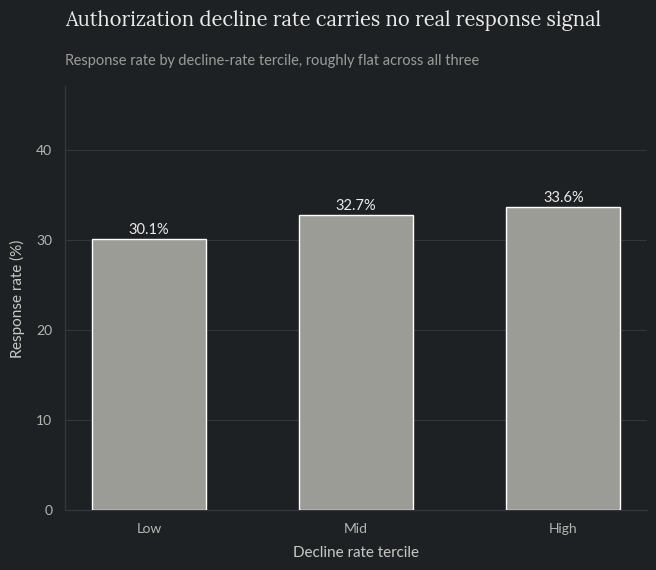

In [5]:
offered["decline_tercile"] = pd.qcut(offered["decline_rate"], 3, labels=["Low", "Mid", "High"])
decline_rates = offered.groupby("decline_tercile", observed=True)["responded"].mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.bar(decline_rates.index.astype(str), decline_rates.values, color=GREY, width=0.55, zorder=3)
for i, v in enumerate(decline_rates.values):
    ax.text(i, v + 0.6, f"{v:.1f}%", ha="center", fontsize=10.5, color=INK)
ax.set_ylim(0, max(decline_rates.values) * 1.4)
style_ax(ax, title="Authorization decline rate carries no real response signal",
         subtitle="Response rate by decline-rate tercile, roughly flat across all three",
         xlabel="Decline rate tercile", ylabel="Response rate (%)")
plt.show()

**Figure 3.** Response rate by checkout authorization decline-rate tercile: `decline_rate` is a decoy feature by construction, it has zero true weight in the response-generating formula, and the data bears that out (a few points of spread here is noise, not signal, against an 18-point spread across recency bands and a 14-point spread across value terciles).

Both real signals move in the expected direction, and by a wide margin: recency shows a clear inverted-U (Figure 1), and lifetime order count, an observable proxy for a customer's long-run value that current-window behavior alone doesn't carry, shows a clean monotonic climb (Figure 2). Decline rate stays flat (Figure 3), exactly what a decoy feature should look like before it ever reaches a model.

## 3. Segmentation: Gaussian Mixture Model

Clusters customers on current-window behavior only (recency, frequency, monetary, category diversity, decline rate), log-transformed and standardized first: raw scales are wildly different and right-skewed, which would otherwise let monetary value dominate purely by having the largest raw scale.

Component count is chosen by BIC (Bayesian Information Criterion), a likelihood-based penalty that stops the model from just picking the largest cluster count tried. BIC never elbows within a reasonable search range here, typical once there's enough data that the complexity penalty barely bites, so candidates are capped at a business-interpretable size (k <= 6) and the minimum is taken within that cap.

BIC by k: {2: np.float64(118647.2), 3: np.float64(90440.9), 4: np.float64(67305.3), 5: np.float64(66192.4), 6: np.float64(65880.6), 7: np.float64(65606.2)}
Selected k=6 (min BIC among k<=6)


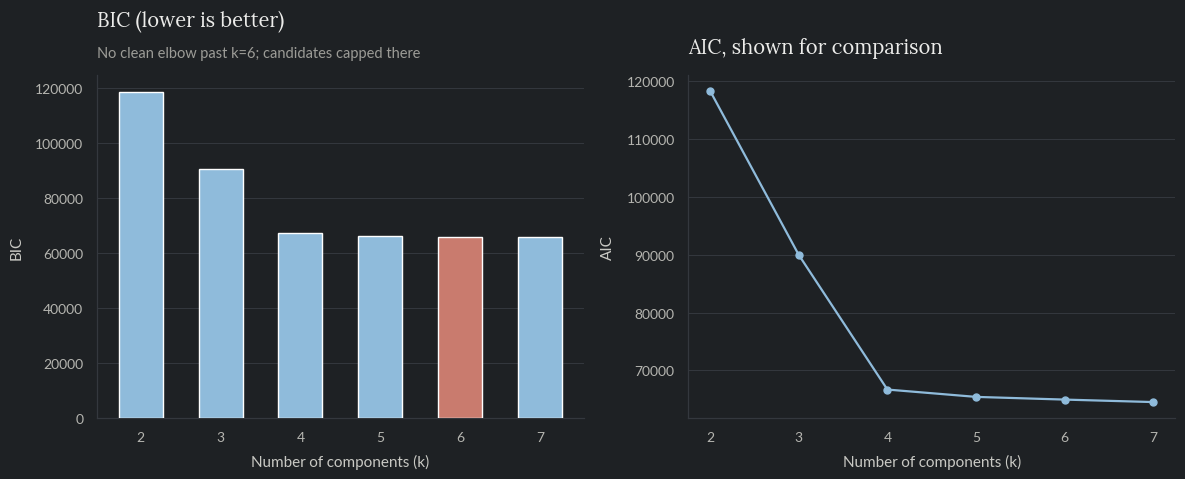

In [6]:
log_features = np.column_stack([
    np.log1p(df["recency_days"]), np.log1p(df["frequency_90d"]), np.log1p(df["monetary_90d"]),
    df["category_diversity"], df["decline_rate"],
])
X = StandardScaler().fit_transform(log_features)

bics, aics = [], []
for k in K_RANGE:
    gmm_k = GaussianMixture(n_components=k, random_state=7, n_init=5).fit(X)
    bics.append(gmm_k.bic(X))
    aics.append(gmm_k.aic(X))

candidates = [k for k in K_RANGE if k <= MAX_INTERPRETABLE_K]
candidate_bics = [bics[list(K_RANGE).index(k)] for k in candidates]
best_k = candidates[int(np.argmin(candidate_bics))]
print(f"BIC by k: {dict(zip(K_RANGE, [round(b, 1) for b in bics]))}")
print(f"Selected k={best_k} (min BIC among k<={MAX_INTERPRETABLE_K})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_bic = [MUTED_RED if k == best_k else SLATE for k in K_RANGE]
axes[0].bar([str(k) for k in K_RANGE], bics, color=colors_bic, zorder=3, width=0.55)
style_ax(axes[0], title="BIC (lower is better)", subtitle=f"No clean elbow past k={MAX_INTERPRETABLE_K}; candidates capped there",
         xlabel="Number of components (k)", ylabel="BIC")
axes[1].plot(list(K_RANGE), aics, color=SLATE, marker="o", markersize=5, linewidth=1.6)
style_ax(axes[1], title="AIC, shown for comparison", xlabel="Number of components (k)", ylabel="AIC")
plt.tight_layout()
plt.show()

**Figure 4.** GMM component selection: BIC and AIC by number of components.

In [7]:
gmm = GaussianMixture(n_components=best_k, random_state=7, n_init=5).fit(X)
df["cluster"] = gmm.predict(X)

profile = df.groupby("cluster")[SEGMENT_FEATURES].mean()
label_map = label_segments(profile)
df["segment"] = df["cluster"].map(label_map)
profile.index = profile.index.map(label_map)
profile = profile.reindex(NAME_SETS[best_k])
profile.round(2)

,recency_days,frequency_90d,monetary_90d,category_diversity,decline_rate
cluster,,,,,
High-Value Active,44.89,8.74,479.18,3.96,0.28
Steady Regular,5.93,8.39,454.94,4.33,0.27
Occasional,109.14,5.08,276.08,2.56,0.25
Light Spender,69.99,4.42,238.18,3.39,0.20
Lapsed,124.30,1.52,83.71,1.52,0.20
Dormant,147.43,0.00,0.00,1.00,0.19


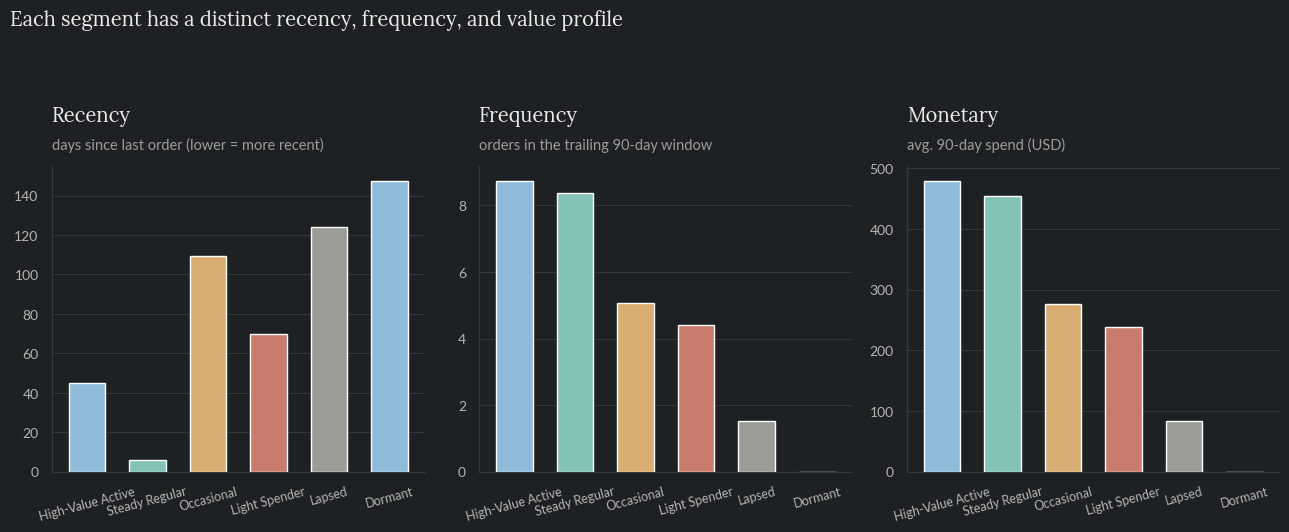

In [8]:
panels = [("recency_days", "Recency", "days since last order (lower = more recent)"),
          ("frequency_90d", "Frequency", "orders in the trailing 90-day window"),
          ("monetary_90d", "Monetary", "avg. 90-day spend (USD)")]
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (col, label, sublabel) in zip(axes, panels):
    ax.bar(profile.index, profile[col], color=PALETTE[:len(profile)], width=0.6, zorder=3)
    style_ax(ax, title=label, subtitle=sublabel, grid_axis="y")
    ax.tick_params(axis="x", labelsize=9, rotation=15)
fig.suptitle("Each segment has a distinct recency, frequency, and value profile",
             x=0.01, y=1.06, ha="left", fontsize=14.5, fontfamily="Lora", color=INK)
plt.tight_layout()
plt.show()

**Figure 5.** Segment behavioral profiles: recency, frequency, and monetary value by segment.

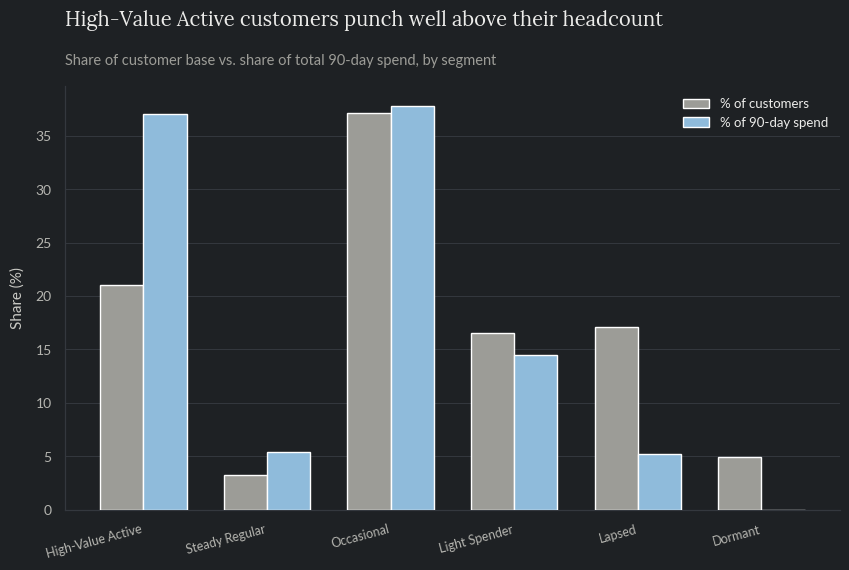

,customers,spend,pct_customers,pct_spend
cluster,,,,
High-Value Active,2525,1209921.0,21.0,37.1
Steady Regular,385,175152.0,3.2,5.4
Occasional,4462,1231861.1,37.2,37.8
Light Spender,1989,473733.9,16.6,14.5
Lapsed,2048,171437.6,17.1,5.3
Dormant,591,0.0,4.9,0.0


In [9]:
seg_summary = df.groupby("segment").agg(customers=("customer_id", "count"), spend=("monetary_90d", "sum")).reindex(profile.index)
seg_summary["pct_customers"] = seg_summary["customers"] / seg_summary["customers"].sum() * 100
seg_summary["pct_spend"] = seg_summary["spend"] / seg_summary["spend"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(seg_summary))
width = 0.35
ax.bar(x - width/2, seg_summary["pct_customers"], width, color=GREY, label="% of customers", zorder=3)
ax.bar(x + width/2, seg_summary["pct_spend"], width, color=SLATE, label="% of 90-day spend", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(seg_summary.index, rotation=15, ha="right", fontsize=9)
style_ax(ax, title="High-Value Active customers punch well above their headcount",
         subtitle="Share of customer base vs. share of total 90-day spend, by segment", ylabel="Share (%)")
ax.legend(loc="upper right", fontsize=9.5)
plt.show()
seg_summary.round(1)

**Figure 6.** Share of customers vs. share of 90-day spend, by segment.

High-Value Active is 21% of customers and 37% of spend; Dormant is 5% of customers and effectively 0% of current spend, the segment a flat "target everyone dormant" rule would waste the most budget on, and exactly the question the propensity model below is built to answer: within a behaviorally-defined segment like Lapsed or Dormant, who's actually worth reaching?

## 4. Propensity model: logistic baseline vs. gradient boosting

Trained on the labeled subset only (customers who were actually sent the past campaign), then scored against the full customer base, since the goal is to rank everyone, offered or not, for the next campaign.

At a ~32% response rate, positive and negative cases aren't sharply imbalanced, so ROC-AUC is a reasonable headline metric here alongside PR-AUC. Isotonic calibration, fit on a held-out validation split, matters here because the budget-constrained targeting analysis in Section 6 needs probabilities that are actually trustworthy, not just well-ranked.

In [10]:
X_full = build_features(df)
offered_mask = df["past_offer_sent"] == 1
X_offered = X_full[offered_mask].reset_index(drop=True)
y_offered = df.loc[offered_mask, "responded"].astype(int).reset_index(drop=True)

X_train, X_temp, y_train, y_temp = train_test_split(X_offered, y_offered, test_size=0.4, stratify=y_offered, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

scaler = StandardScaler()
logit = LogisticRegression(max_iter=2000).fit(scaler.fit_transform(X_train), y_train)
logit_auc = roc_auc_score(y_test, logit.predict_proba(scaler.transform(X_test))[:, 1])

gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.08, max_iter=300, min_samples_leaf=40, random_state=42)
gbm.fit(X_train, y_train)
calibrated = CalibratedClassifierCV(gbm, method="isotonic", cv="prefit")
calibrated.fit(X_val, y_val)

y_prob_raw = gbm.predict_proba(X_test)[:, 1]
y_prob_test = calibrated.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
print(f"Logistic regression baseline AUC: {logit_auc:.4f}")
print(f"GBM test ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f} (base rate {y_test.mean():.1%})")
print(f"Brier score - raw: {brier_score_loss(y_test, y_prob_raw):.4f} | calibrated: {brier_score_loss(y_test, y_prob_test):.4f}")

Train: 3,187 | Val: 1,063 | Test: 1,063


Logistic regression baseline AUC: 0.7059
GBM test ROC-AUC: 0.7166 | PR-AUC: 0.5233 (base rate 32.1%)
Brier score - raw: 0.1896 | calibrated: 0.1904


/sessions/bold-gallant-ptolemy/.local/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


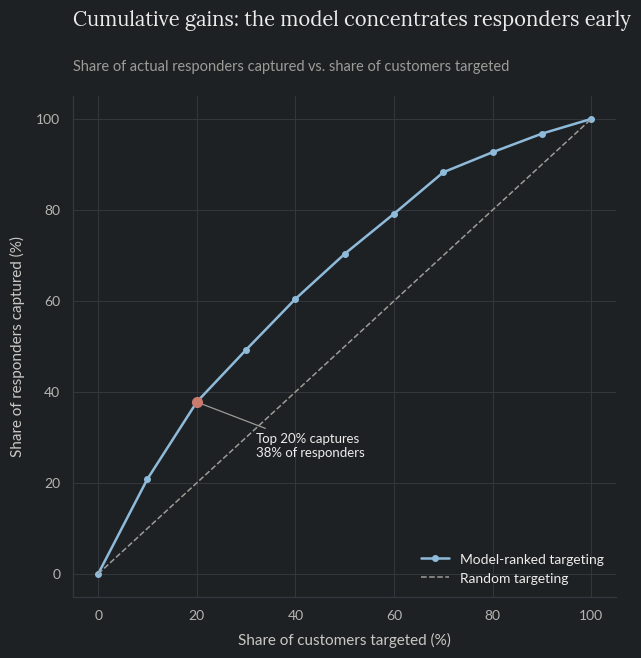

In [11]:
pop_share, capture_share = cumulative_gains(y_test.values, y_prob_test)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(pop_share * 100, capture_share * 100, color=SLATE, linewidth=1.8, marker="o", markersize=4, label="Model-ranked targeting")
ax.plot([0, 100], [0, 100], "--", color=GREY, linewidth=1.1, label="Random targeting")
top20_capture = np.interp(20, pop_share * 100, capture_share * 100)
ax.plot([20], [top20_capture], marker="o", markersize=7, color=MUTED_RED, zorder=5)
ax.annotate(f"Top 20% captures\n{top20_capture:.0f}% of responders", xy=(20, top20_capture),
            xytext=(32, top20_capture - 12), fontsize=9.5, color=INK,
            arrowprops={"arrowstyle": "-", "color": GREY, "linewidth": 0.9})
style_ax(ax, title="Cumulative gains: the model concentrates responders early",
         subtitle="Share of actual responders captured vs. share of customers targeted",
         xlabel="Share of customers targeted (%)", ylabel="Share of responders captured (%)", grid_axis="both")
ax.legend(loc="lower right")
plt.show()

**Figure 7.** Cumulative gains chart on the held-out test set: model-ranked targeting vs. random.

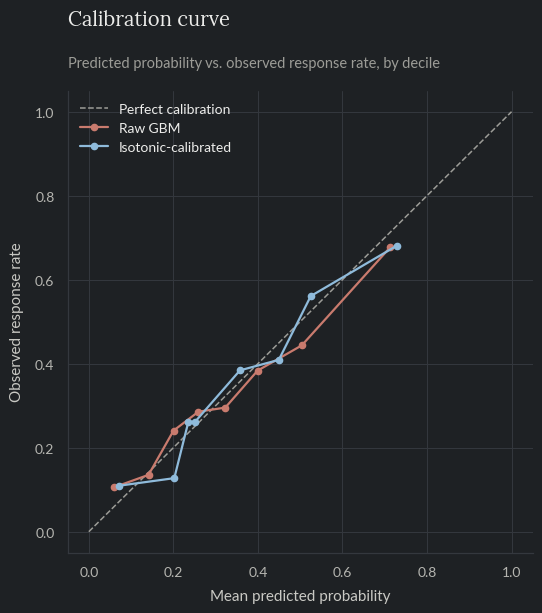

In [12]:
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_prob_raw, n_bins=8, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_test, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color=GREY, linewidth=1.1, label="Perfect calibration")
ax.plot(mean_pred_raw, frac_pos_raw, marker="o", markersize=4.5, color=MUTED_RED, linewidth=1.6, label="Raw GBM")
ax.plot(mean_pred_cal, frac_pos_cal, marker="o", markersize=4.5, color=SLATE, linewidth=1.6, label="Isotonic-calibrated")
style_ax(ax, title="Calibration curve", subtitle="Predicted probability vs. observed response rate, by decile",
         xlabel="Mean predicted probability", ylabel="Observed response rate", grid_axis="both")
ax.legend(loc="upper left")
plt.show()

**Figure 8.** Calibration curve, raw GBM vs. isotonic-calibrated, held-out test set.

The GBM edges out the logistic baseline on AUC (0.717 vs. 0.706), a modest lift that makes sense given the response formula's one genuinely non-linear term (the recency "sweet spot" is a peak, not a straight line, which a tree model captures far more naturally than a linear one). The gains chart (Figure 7) is the more decision-relevant view: targeting the top 20% by predicted score captures roughly 38% of actual responders, nearly double what random targeting would get for the same budget.

## 5. Interpretability (SHAP)

Checks whether the model actually leans on the baseline-value proxies (`lifetime_orders`, `tenure_days`) and the recency sweet spot, the same signals the response label was generated from in `src/generate_data.py`, and that the decoy `decline_rate` feature doesn't rank highly.

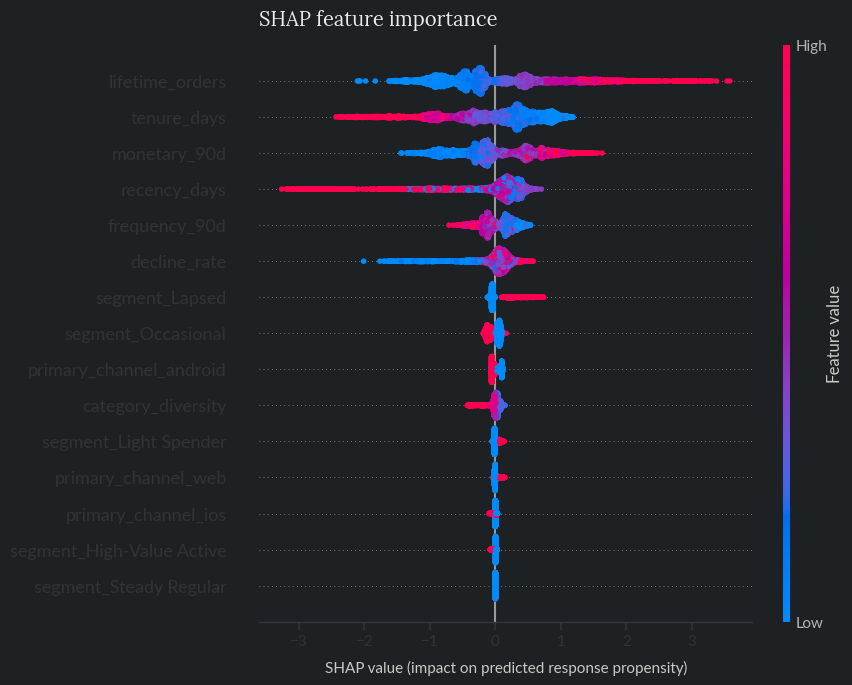

In [13]:
explainer = shap.TreeExplainer(gbm)
shap_values = explainer(X_offered)

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_offered, show=False, max_display=15, plot_size=None)
ax = plt.gca()
ax.set_title("SHAP feature importance", loc="left", fontsize=14.5, fontweight="normal", fontfamily="Lora", color=INK, pad=14)
ax.set_xlabel("SHAP value (impact on predicted response propensity)", fontsize=11, labelpad=8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Figure 9.** SHAP feature importance on the offered customers.

In [14]:
mean_abs = pd.Series(abs(shap_values.values).mean(axis=0), index=list(X_offered.columns)).sort_values(ascending=False)
decline_rank = int(mean_abs.rank(ascending=False)["decline_rate"])
print(f"decline_rate ranks {decline_rank} of {len(mean_abs)}")
mean_abs.head(10)

decline_rate ranks 6 of 16


lifetime_orders            0.694444
tenure_days                0.542091
monetary_90d               0.458483
recency_days               0.368952
frequency_90d              0.188269
decline_rate               0.181509
segment_Lapsed             0.092210
segment_Occasional         0.074740
primary_channel_android    0.053352
category_diversity         0.046643
dtype: float64

SHAP recovers the intended ranking: `lifetime_orders` and `tenure_days`, the two observable proxies for the latent `baseline_value` trait, dominate, followed by `monetary_90d` and `recency_days` (the sweet-spot signal). The decoy `decline_rate` ranks 6th of 16, a real but secondary signal, not a top driver, exactly what a well-behaved model should do with a feature that has zero true weight in the generating formula.

## 6. Budget-constrained targeting

The growth team can only afford to reach a fixed share of the customer base with the next campaign. Compares three ways to pick who gets it: random targeting, a naive "target the biggest spenders" rule, and ranking by the calibrated propensity score.

Expected responders under each policy is computed from the model's own calibrated propensity score, since that's the only response-rate estimate available for customers who were never actually offered anything. This step isn't re-validating the model (Figure 7 and the held-out AUC already did that): it's a downstream decision analysis built on a model already shown to rank held-out responders well.

In [15]:
all_probs = calibrated.predict_proba(X_full)[:, 1]
scores = df[["customer_id", "segment", "past_offer_sent", "monetary_90d"]].copy()
scores["propensity_score"] = all_probs

n = len(scores)
budget_n = round(BUDGET_FRACTION * n)
random_expected = budget_n * scores["propensity_score"].mean()
topspend_expected = expected_responders(scores, "monetary_90d", budget_n)
model_expected = expected_responders(scores, "propensity_score", budget_n)

print(f"Budget: top {BUDGET_FRACTION:.0%} of customers ({budget_n:,} of {n:,})")
print(f"Expected responders - random: {random_expected:.0f} | top-spend: {topspend_expected:.0f} | model-ranked: {model_expected:.0f}")
print(f"Model lift vs. random: {model_expected / random_expected - 1:.1%} | vs. top-spend: {model_expected / topspend_expected - 1:.1%}")

Budget: top 20% of customers (2,400 of 12,000)
Expected responders - random: 734 | top-spend: 1104 | model-ranked: 1425
Model lift vs. random: 94.0% | vs. top-spend: 29.1%


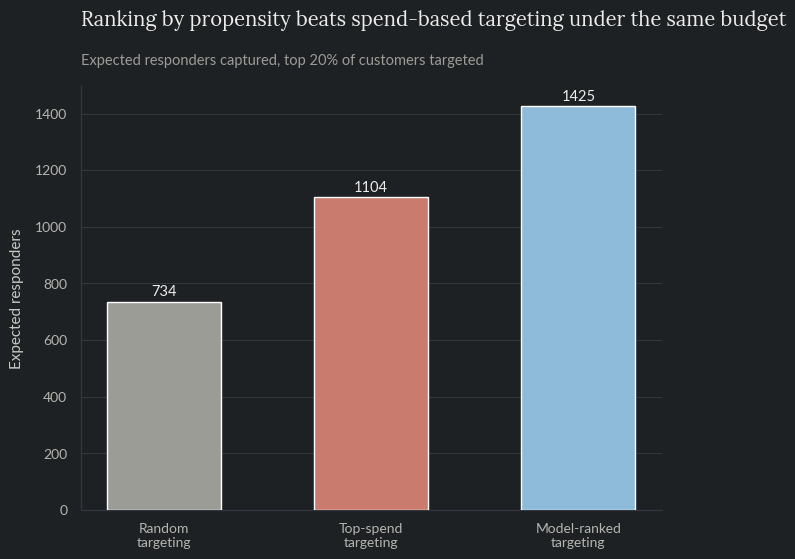

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
policies = ["Random\ntargeting", "Top-spend\ntargeting", "Model-ranked\ntargeting"]
vals = [random_expected, topspend_expected, model_expected]
ax.bar(policies, vals, color=[GREY, MUTED_RED, SLATE], width=0.55, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + max(vals) * 0.015, f"{v:.0f}", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Ranking by propensity beats spend-based targeting under the same budget",
         subtitle=f"Expected responders captured, top {BUDGET_FRACTION:.0%} of customers targeted", ylabel="Expected responders")
plt.show()

**Figure 10.** Expected responders captured under each targeting policy, same fixed budget.

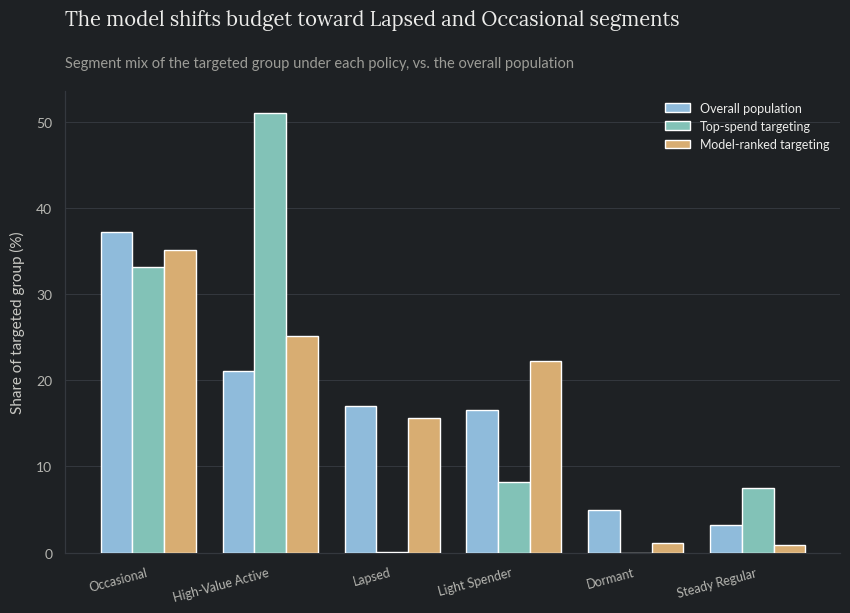

,Overall population,Top-spend targeting,Model-ranked targeting
segment,,,
Occasional,37.2,33.2,35.1
High-Value Active,21.0,51.0,25.1
Lapsed,17.1,0.0,15.6
Light Spender,16.6,8.2,22.2
Dormant,4.9,0.0,1.1
Steady Regular,3.2,7.5,0.9


In [17]:
overall_mix = scores["segment"].value_counts(normalize=True) * 100
model_top = scores.sort_values("propensity_score", ascending=False).head(budget_n)
topspend_top = scores.sort_values("monetary_90d", ascending=False).head(budget_n)
segments = list(overall_mix.index)
mix_df = pd.DataFrame({
    "Overall population": overall_mix.reindex(segments).fillna(0),
    "Top-spend targeting": (topspend_top["segment"].value_counts(normalize=True) * 100).reindex(segments).fillna(0),
    "Model-ranked targeting": (model_top["segment"].value_counts(normalize=True) * 100).reindex(segments).fillna(0),
})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(segments))
width = 0.26
for i, col in enumerate(mix_df.columns):
    ax.bar(x + (i - 1) * width, mix_df[col], width, color=PALETTE[i], label=col, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(segments, rotation=15, ha="right", fontsize=9)
style_ax(ax, title="The model shifts budget toward Lapsed and Occasional segments",
         subtitle="Segment mix of the targeted group under each policy, vs. the overall population", ylabel="Share of targeted group (%)")
ax.legend(loc="upper right", fontsize=9)
plt.show()
mix_df.round(1)

**Figure 11.** Segment composition of the targeted group under each policy.

Ranking by propensity captures 94% more expected responders than random targeting and 29% more than the naive top-spend rule, for the exact same budget (Figure 10). The mechanism is visible in the segment mix (Figure 11): top-spend targeting puts 51% of its budget on High-Value Active customers, who'd very plausibly have kept spending anyway, and 0% on Lapsed customers. The propensity model does the opposite, cutting High-Value Active down to 25% and putting 16% of the budget on Lapsed, the segment a flat behavioral rule would most undersell, since "Lapsed" and "Dormant" look similar on current behavior alone but differ sharply in the historical-value proxies the model has access to.

## 7. Recommendation

Use the propensity-ranked targeting policy for the next campaign over a spend-based or behavioral-segment-only rule: it captures meaningfully more expected responders under the same budget, and it does so by reaching a different set of customers than a naive rule would, concentrating on Lapsed and Occasional customers with a strong historical-value signal rather than customers who'd likely respond (or spend) regardless of any offer.

Segmentation alone remains useful for reporting and coarse resource planning (which segments exist, how large they are, how much current spend they represent), but it isn't a substitute for the propensity model when the actual decision is who gets a limited-budget offer: the SHAP results show the model leans on `lifetime_orders` and `tenure_days`, two behavioral-history proxies segmentation in Section 3 never sees, since that segmentation is built entirely from current-window features.

Re-derive the propensity model whenever the campaign, offer, or eligible population changes meaningfully, and revisit the segmentation independently on its own cadence: the two are complementary views of the same customer base, each useful for a different decision.

## 8. Limitations

- Synthetic data with a hand-specified, mostly-linear response function (plus one deliberate non-linearity, the recency sweet spot). Real response behavior is noisier and less stationary: what drives a customer to respond to a win-back offer today may not hold six months from now.
- The past campaign wasn't randomized (it leaned toward moderately lapsed, established accounts), so the propensity model is a response-ranking tool, not a causal estimate of the offer's incremental effect. Measuring the offer's true incremental lift would need a randomized holdout test, which the growth team didn't run for this campaign.
- GMM component count is capped at a business-interpretable size (k <= 6) rather than the unconstrained BIC minimum, a judgment call, not a statistically derived cutoff.
- Expected responders under a fixed budget are computed entirely from the model's own calibrated propensity score, since no ground-truth response exists for customers who were never offered anything; this is standard practice for scoring an unlabeled population, but it means the budget analysis is only as good as the calibration step it depends on.